<h1>Clusterig Analysis - Case Studies</h1>

In [3]:
import warnings
warnings.filterwarnings("ignore")

<h2>Wine Dataset Clustering</h2>

In [4]:
import pandas as pd


wine_df = pd.read_csv('../datasets/wine-clustering.csv')
wine_df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


<h2>Case Study 1: 2D clustering </h2>
<ul>
    <li>Provide a Scatter plot of Wine data based on their color_intensity and Alcohol levels</li>
    <li>Using K-Means clustering, and using k-optimality indexes, group the data in their most optimal clusters</li>
    <li style="color:blue">Compare the results of K-Means clustering with that of Hierarchical Clustering</li>
    <li style="color:blue">Compare the results of K-Means clustering with that of Gaussian Mixture Models</li>
</ul>

<h3>Answer A - Scatter Plot</h3>

<h3>Answer A2 - Silhouette Score</h3>

<h3>Display Clusters as the Silhouette Method</h3>

<h3>Answer A3 - Elbow method</h3>

<h3>Display Clusters as the Elbow Method</h3>

<h3>Answer B - Hierarchical Clustering</h3>

<h3>Display Clusters as per HC</h3>

<h3>Answer C - Gaussian Mixture Models [Find Optimal K as per Silhouette Method]</h3>

<h3>Display Clusters as per the Silhouette Approach</h3>

<h3>Display Clusters as per the Elbow Method</h3>

In [5]:
def gmm_wcss(gmm, X):
    """
    Compute inertia-like WCSS for a fitted GaussianMixture model.
    """
    # Responsibilities matrix N x K
    responsibilities = gmm.predict_proba(X)

    # Cluster means (K x d)
    means = gmm.means_

    # Compute squared distances (N x K)
    sq_dists = np.zeros((X.shape[0], gmm.n_components))
    for k in range(gmm.n_components):
        diff = X - means[k]
        sq_dists[:, k] = np.sum(diff * diff, axis=1)

    # Weighted sum (soft assignments)
    wcss = np.sum(responsibilities * sq_dists)
    return wcss

<h2>Case Study 2: nD clustering</h2>
<ul>
    <li>Make use of PCA to transform the datasets and evaluate the contribution of the first two principal components to
    variance explanation</li>
    <li>Use the first two principal components to visualise the entire datasets in 2D</li>
    <li>Using K-Means clustering, and using k-optimality indexes, group the data in their most optimal clusters</li>
    <li>Visualise your cluster group using their PCA representation in 2D</li>
    <li style="color:blue">Compare the results of K-Means clustering with that of Hierarchical Clustering</li>
    <li style="color:blue">Compare the results of K-Means clustering with that of Gaussian Mixture Models</li>
</ul>

<h3>Answer A - PCA Transformation</h3>

<h3>Answer A2 - PCA 2D Visualisation</h3>

<h3>Answer A3 - K-Means Clustering (Silhouette Method)</h3>

<h3>Answer A4 - K-Means Clustering Clusters Visualisation</h3>

<h2>Case Study 3: Cluster Group Interpretation [Take Home Assessment]</h2>
<ul style="color:blue">
    <li>From the cluster groups obtained from Case Study 2 - Generate a labelled datasets with cluster labels as target values</li>
    <li>Choose a subset of explanatory features from the data: Use all initially</li>
    <li>Split your dataset into Training and Test set</li>
    <li>Build a decision tree in its optimal configuration (Hyperparameter tuning)</li>
    <li>Assess the model performance in terms of F1 score and classification accuracy</li>
    <li>Visualise your decision tree rules to get insights on each cluster subset</li>
</ul>

<h2>Annexe: Silhouette Score</h2>

The silhouette score estimates how poor or well is a data point dissimilarity within the assigned cluster than outside the cluster by computing two dissimilarity measures:

\begin{equation}
    a(x_i) = \frac{1}{N_p-1}\sum_{j,x_i\neq x_j\in C_p}^{N_p-1}d(x_i,x_j)
\end{equation}
where $a(x_i)$ is the average distance between a data point $x_i$ and all other points within its cluster $C_p$.<br/><br/>
\begin{equation}
    b(x_i) = min\{\mu(x_i,C_j)\},j\neq p
\end{equation}
<br/>where $b(x_i)$ is the smallest average distance between a data point $x_i$ and any other point of all other clusters besides its cluster $C_p$.

The Silhouette score is thus denoted as

\begin{equation}
    s(x_i) = \frac{b(x_i)-a(x_i)}{max\{a(x_i),b(x_i)\}}, s(x_i) \in [-1,1]
\end{equation}<br/>
whereby the largest positive value indicates that the data point is well clustered and the largest negative value that it is poorly clustered. The average silhouette value  (i.e. $s_k=\frac{1}{N}\sum_{i}^{N}s(x_i)$) for all data points is used to rank a given k-Clustering.

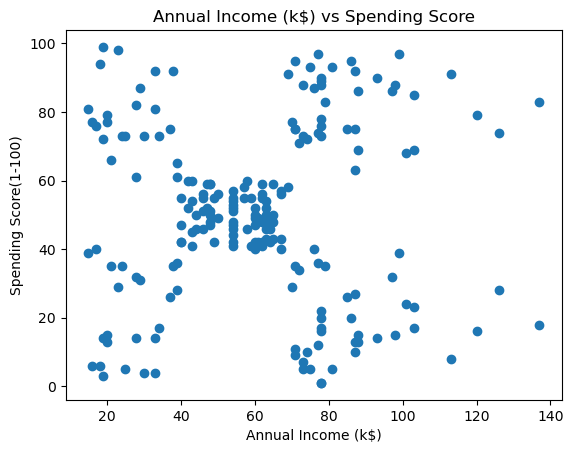

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
warnings.filterwarnings('ignore') #ignore warnings
#load the dataset
df = pd.read_csv('../datasets/OLART_customers.csv')

#select data of interest
sub_df = df.iloc[:,[3,4]] #Annual Income against Spending Score
x_1 = sub_df['Annual Income (k$)']
x_2 = sub_df['Spending Score (1-100)']


plt.figure()
plt.scatter(x_1,x_2)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score(1-100)')
plt.title('Annual Income (k$) vs Spending Score')
plt.show()

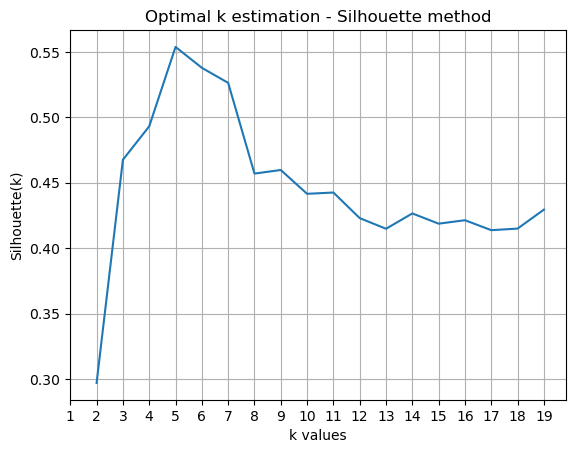

In [7]:
import numpy as np

sv=[]
sv_id = -1
sv_val = -1
for k in range(2,20): #set range k values to search from
    km = KMeans(k)
    km.fit(sub_df)
    score = silhouette_score(sub_df,km.labels_,metric='euclidean')
    if sv_val < score:
        sv_val = score
        sv_id = k
    sv.append(score)
    
plt.figure()
plt.plot(np.arange(2,20),sv)
plt.xticks(range(1,20))
plt.xlabel('k values')
plt.ylabel('Silhouette(k)')
plt.title('Optimal k estimation - Silhouette method')
plt.grid()
plt.show()

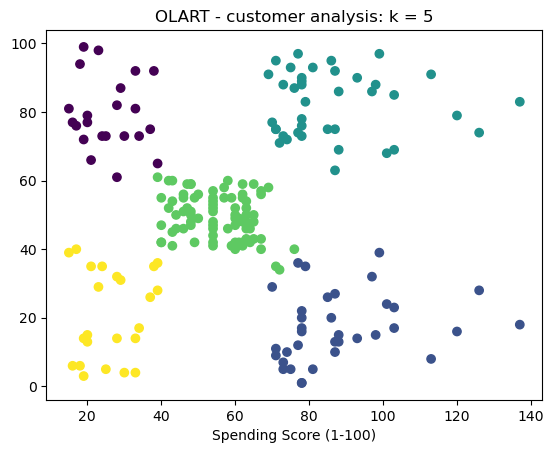

In [8]:
k_choice = sv_id #choice of k
km = KMeans(k_choice)
clusterIds = km.fit_predict(sub_df) #get data group labels

plt.figure()
plt.xlabel(sub_df.columns[0])
plt.xlabel(sub_df.columns[1])
plt.scatter(x_1,x_2,c=clusterIds)
plt.title('OLART - customer analysis: k = %d'%k_choice)
plt.show() 